In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

## EDA(Exploratory Data Analysis)

In [2]:
crimes=pd.read_csv('crimes.csv')
crimes

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST
...,...,...,...,...,...,...,...,...,...,...,...,...
185710,231510379,2023-05-29,2023-05-25,1100,N Hollywood,"BUNCO, GRAND THEFT",25,M,W,NaN,Invest Cont,5300 DENNY AV
185711,231604807,2023-01-27,2023-01-26,1800,Foothill,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",23,M,H,NaN,Invest Cont,12500 BRANFORD ST
185712,231606525,2023-03-22,2023-03-22,1000,Foothill,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",25,F,H,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Invest Cont,12800 FILMORE ST
185713,231210064,2023-04-12,2023-04-12,1630,77th Street,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",29,M,B,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,6100 S VERMONT AV


In [4]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  int64 
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(3), object(9)
memory usage: 17.0+ MB


In [5]:
## Convert the date columns from object to date
crimes['Date Rptd'] = pd.to_datetime(crimes['Date Rptd'])
crimes['DATE OCC'] = pd.to_datetime(crimes['DATE OCC'])

In [7]:
# Extract useful time features
crimes['Year'] = crimes['DATE OCC'].dt.year
crimes['Month'] = crimes['DATE OCC'].dt.month
crimes['Day'] = crimes['DATE OCC'].dt.day
crimes['Hour'] = crimes['TIME OCC'] // 100

In [10]:
# Handle missing categorical values
crimes['Weapon Desc'] = crimes['Weapon Desc'].fillna('No Weapon')
crimes['Vict Sex'] = crimes['Vict Sex'].fillna('Unknown')
crimes['Vict Descent'] = crimes['Vict Descent'].fillna('Unknown')

In [11]:
crimes = crimes[crimes['Vict Age'] > 0]

## Crimes Over Time (Trend Analysis)

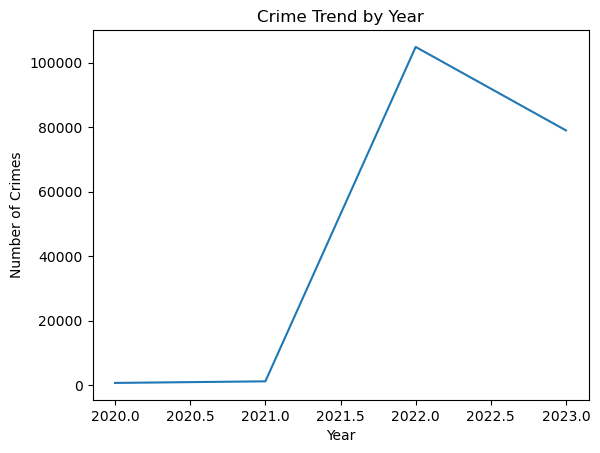

In [12]:
crime_by_year = crimes['Year'].value_counts().sort_index()

plt.figure()
crime_by_year.plot()
plt.title("Crime Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.show()

**Crimes significantly increasing post covid**

## Topp 10 crimes

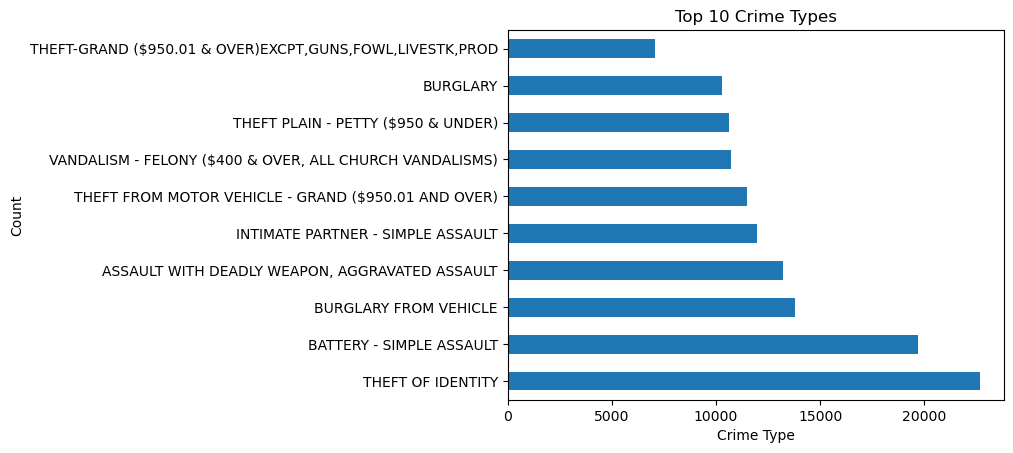

In [18]:
top_crimes = crimes['Crm Cd Desc'].value_counts().nlargest(10)

plt.figure()
top_crimes.plot(kind='barh')
plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.show()

**Identity Theft crimes dominate Los Angeles Charts**

## Crime By Areas

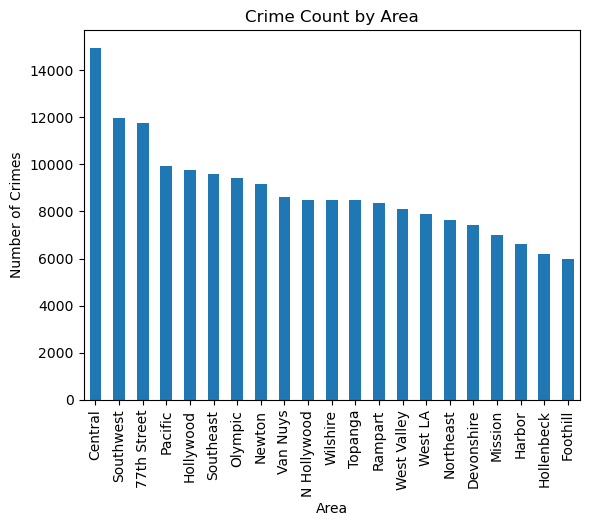

In [20]:
area_crimes = crimes['AREA NAME'].value_counts()

plt.figure()
area_crimes.plot(kind='bar')
plt.title("Crime Count by Area")
plt.xlabel("Area")
plt.ylabel("Number of Crimes")
plt.show()

**These are the High risk zones areas needing policing focus**

## Victim Age Distribution

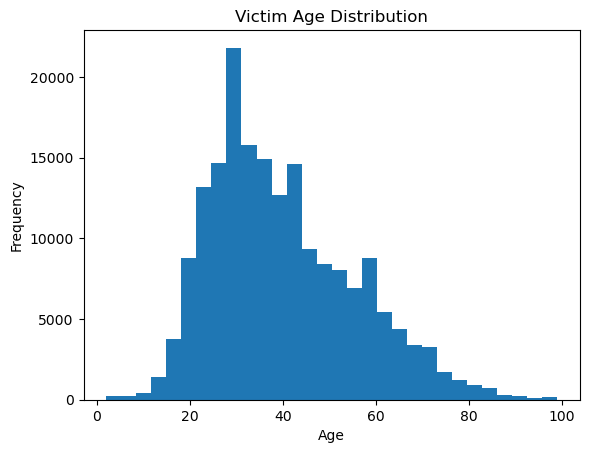

In [21]:
plt.figure()
crimes['Vict Age'].plot(kind='hist', bins=30)
plt.title("Victim Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Victims targeted most are in the age of 25-30** 

## Crimes By Genders

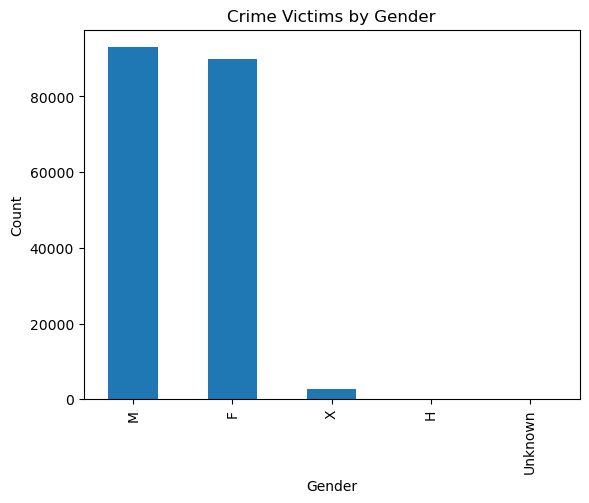

In [23]:
gender_counts = crimes['Vict Sex'].value_counts()

plt.figure()
gender_counts.plot(kind='bar')
plt.title("Crime Victims by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## Weapon Usage

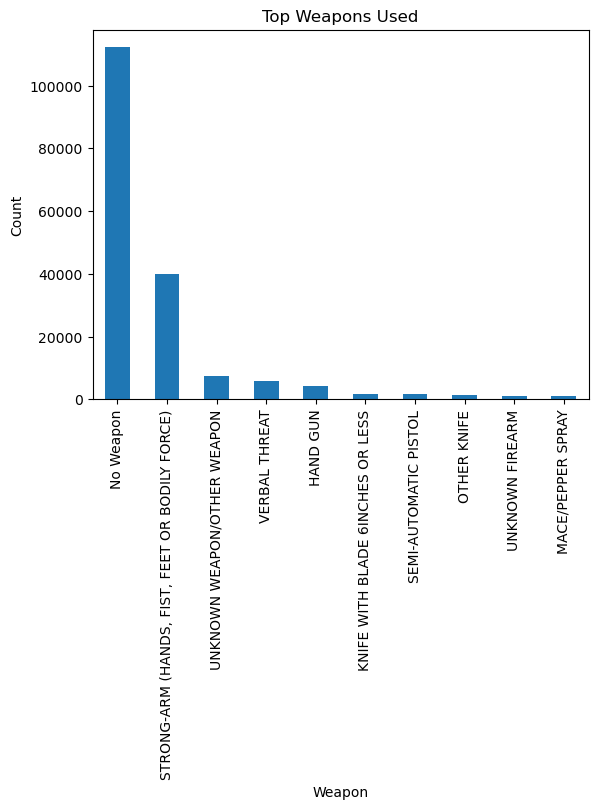

In [25]:
top_weapons = crimes['Weapon Desc'].value_counts().head(10)

plt.figure()
top_weapons.plot(kind='bar')
plt.title("Top Weapons Used")
plt.xlabel("Weapon")
plt.ylabel("Count")
plt.show()

## Time of the day crime occured

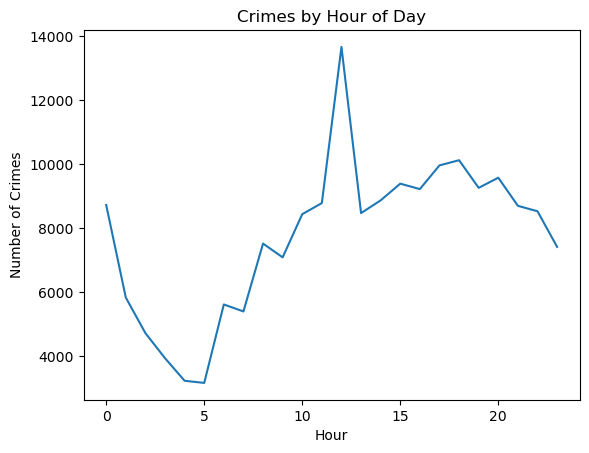

In [26]:
hour_crime = crimes['Hour'].value_counts().sort_index()

plt.figure()
hour_crime.plot()
plt.title("Crimes by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Crimes")
plt.show()

**Crimes are mostly committed at noon**

Final Professional Insights You Should Extract

When writing your project README:

You want insights like:

Theft-related crimes dominate Los Angeles crime reports.

Crime frequency peaks in late evening hours.

Central and high-density urban areas show highest crime concentration.

Majority of victims fall within 20–40 age range.

Most crimes involve no weapon or physical force.